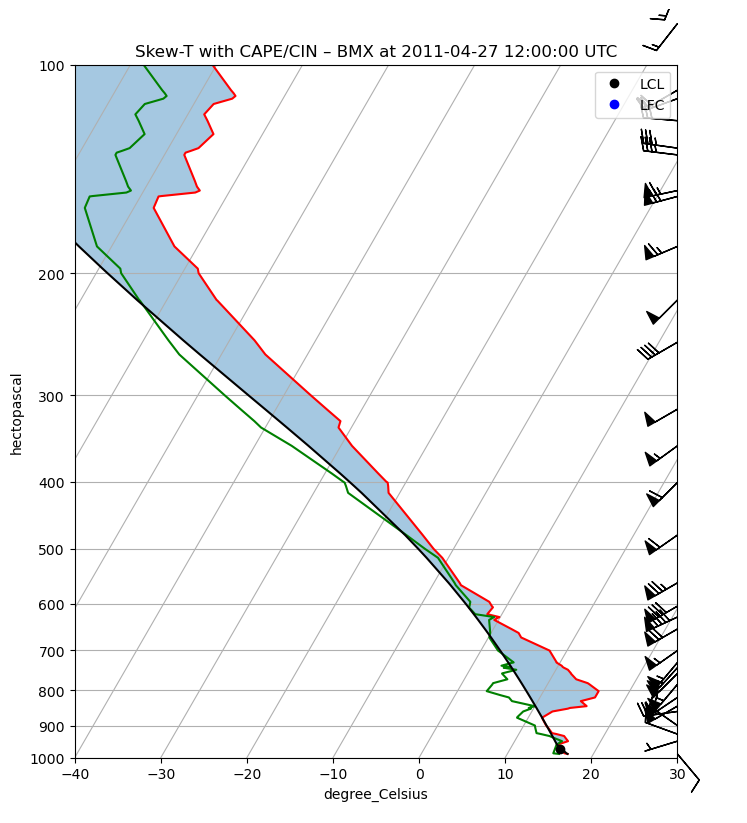

Saved to: /Users/lexfugatt/Desktop/BMX_skewt.png


In [3]:
from datetime import datetime
import os
import matplotlib.pyplot as plt
from metpy.plots import SkewT
from metpy.units import units
from siphon.simplewebservice.wyoming import WyomingUpperAir
import metpy.calc as mpcalc

station = 'BMX'
date = datetime(2011, 4, 27, 12)

df = WyomingUpperAir.request_data(date, station)

df = df.dropna(subset=[
    'temperature',
    'dewpoint',
    'u_wind',
    'v_wind'
])

p = df['pressure'].values * units.hPa
T = df['temperature'].values * units.degC
Td = df['dewpoint'].values * units.degC
u = df['u_wind'].values * units.knots
v = df['v_wind'].values * units.knots

parcel_prof = mpcalc.parcel_profile(
    p,
    T[0],
    Td[0]
).to('degC')

lcl_pressure, lcl_temp = mpcalc.lcl(
    p[0],
    T[0],
    Td[0]
)

lfc_pressure, _ = mpcalc.lfc(
    p,
    T,
    Td
)

fig = plt.figure(figsize=(9, 9))

skew = SkewT(fig)

skew.plot(p, T, 'r')
skew.plot(p, Td, 'g')
skew.plot(p, parcel_prof, 'k')

skew.plot_barbs(
    p[::3],
    u[::3],
    v[::3]
)

skew.shade_cape(p, T, parcel_prof)
skew.shade_cin(p, T, parcel_prof)

skew.ax.plot(
    lcl_temp,
    lcl_pressure,
    'ko',
    markerfacecolor='black',
    label='LCL'
)

if lfc_pressure is not None:
    skew.ax.plot(
        mpcalc.dry_lapse(
            p[0],
            T[0],
            lfc_pressure
        ).magnitude,
        lfc_pressure.magnitude,
        'bo',
        markerfacecolor='blue',
        label='LFC'
    )

skew.ax.set_ylim(1000, 100)
skew.ax.set_xlim(-40, 30)

skew.ax.set_title(
    f"Skew-T with CAPE/CIN – BMX at {date} UTC"
)

skew.ax.legend()

desktop = os.path.join(
    os.path.expanduser("~"),
    "Desktop",
    "BMX_skewt.png"
)

plt.savefig(
    desktop,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(f"Saved to: {desktop}")